In [130]:
import polars as ps
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, make_scorer
import spyndex as spx
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
from amini_canopy.config import *

2025-03-30 09:35:01.715 | INFO     | amini_canopy.config:<module>:11 - PROJ_ROOT path is: D:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge


Preview train and test data

In [4]:
train_data_path = RAW_DATA_DIR / "Train.csv"
raw_train_df = pd.read_csv(train_data_path)

In [5]:
raw_train_df.head(5)

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
0,1D_0000,2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,1D_0000,2021-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,1D_0000,2021-01-14,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
3,1D_0000,2021-01-19,0.1095,0.1357,0.0858,0.1596,0.0782,0.0330,0.0873,0.1620,0.1396,0.1736,0.1820,0.0260,0.0011,0.300733,0.342304,-0.186176,0.008666,0.0
4,1D_0000,2021-01-24,0.1128,0.1300,0.0919,0.2141,0.1240,0.0608,0.1035,0.1546,0.1845,0.2302,0.2606,0.0703,0.0041,0.399346,0.266489,-0.309881,0.059365,0.0


Check unique row ids

In [6]:
unique_row_ids = raw_train_df['ID'].unique()
print(f"Number of unique row ids: {len(unique_row_ids)}")

Number of unique row ids: 26219


Check missing values

In [7]:
missing_values_by_id = raw_train_df.groupby('ID'
                                            ).agg(lambda x: x.isnull().sum())
                                        
missing_values_by_id

,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
ID,,,,,,,,,,,,,,,,,,,
1D_0000,0,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,0
1D_0001,0,87,87,87,87,87,87,87,87,87,87,87,87,87,87,87,87,87,0
1D_0002,0,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,0
1D_0003,0,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,0
1D_0004,0,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,91,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_362150a4e,0,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,0
id_36251804e,0,90,90,90,90,90,90,90,90,90,90,90,90,90,90,90,90,90,0
id_362957e2b,0,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,0


In [8]:
non_values_by_id = raw_train_df.groupby('ID').agg(lambda group: group.notnull().sum())
non_values_by_id.head()

,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
ID,,,,,,,,,,,,,,,,,,,
1D_0000,279,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,279
1D_0001,279,192,192,192,192,192,192,192,192,192,192,192,192,192,192,192,192,192,279
1D_0002,279,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,279
1D_0003,279,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,279
1D_0004,279,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,188,279


In [9]:
timeseries = raw_train_df.groupby('ID').agg({'ID': 'count'})
timeseries.head()

,ID
ID,
1D_0000,279
1D_0001,279
1D_0002,279
1D_0003,279
1D_0004,279


In [10]:
# Ensure the 'time' column is in datetime format
raw_train_df['time'] = pd.to_datetime(raw_train_df['time'], errors='coerce')

# Calculate the time range for each unique ID
time_range_by_id = raw_train_df.groupby('ID').agg(
    time_range=('time', lambda x: (x.max() - x.min()).days if not x.isnull().all() else None)
)

time_range_by_id.head()

,time_range
ID,
1D_0000,1395
1D_0001,1395
1D_0002,1395
1D_0003,1395
1D_0004,1395


In [11]:
unique_pixel_observations = raw_train_df['ID'].sort_values().value_counts()
unique_pixel_observations.head()

ID
1D_0ABB    555
1D_0ABC    555
1D_0ABF    555
1D_0AC2    555
1D_0AC3    555
Name: count, dtype: int64

Fill missing values using forward fill

In [12]:
# Calculate the number of unique pixel observations for each unique ID
corrected_train_data = raw_train_df.bfill()
corrected_train_data.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
0,1D_0000,2021-01-04,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
1,1D_0000,2021-01-09,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
2,1D_0000,2021-01-14,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
3,1D_0000,2021-01-19,0.1095,0.1357,0.0858,0.1596,0.0782,0.0330,0.0873,0.1620,0.1396,0.1736,0.1820,0.0260,0.0011,0.300733,0.342304,-0.186176,0.008666,0.0
4,1D_0000,2021-01-24,0.1128,0.1300,0.0919,0.2141,0.1240,0.0608,0.1035,0.1546,0.1845,0.2302,0.2606,0.0703,0.0041,0.399346,0.266489,-0.309881,0.059365,0.0


In [13]:
grouped_data = corrected_train_data.groupby('ID')
new_df = pd.DataFrame()
dfs = []
for group in grouped_data:
    chip_data = grouped_data.get_group(group[0]).bfill().ffill()
    dfs.append(chip_data)
new_df = pd.concat(dfs)
new_df.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
0,1D_0000,2021-01-04,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
1,1D_0000,2021-01-09,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
2,1D_0000,2021-01-14,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
3,1D_0000,2021-01-19,0.1095,0.1357,0.0858,0.1596,0.0782,0.0330,0.0873,0.1620,0.1396,0.1736,0.1820,0.0260,0.0011,0.300733,0.342304,-0.186176,0.008666,0.0
4,1D_0000,2021-01-24,0.1128,0.1300,0.0919,0.2141,0.1240,0.0608,0.1035,0.1546,0.1845,0.2302,0.2606,0.0703,0.0041,0.399346,0.266489,-0.309881,0.059365,0.0


Feature Engineering

Derive indices for detecting canopy from raw spectral indices

In [14]:
%%script echo skipping
# Calculate vegetation indices
new_df['CSI'] = (new_df['SWIR1'] - new_df['NIR']) / (new_df['SWIR1'] + new_df['NIR'])  # Canopy/Shadow Index
new_df['BSI'] = ((new_df['SWIR1'] + new_df['RED']) - (new_df['NIR'] + new_df['Blue'])) / \
                ((new_df['SWIR1'] + new_df['RED']) + (new_df['NIR'] + new_df['Blue']))  # Bare Soil Index
new_df['AVI'] = (new_df['NIR'] * (1 - new_df['RED']) * (new_df['NIR'] - new_df['RED'])) ** 0.333  # Advanced Vegetation Index

# Display the first few rows of the dataframe with the new indices
new_df[['ID', 'time', 'NDVI', 'LAI', 'CSI', 'BSI', 'AVI']].head()

skipping


In [15]:
test_data_path = RAW_DATA_DIR / "Test.csv"
raw_test_data = pd.read_csv(test_data_path)
raw_test_data.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI
0,1D_0005,2021-01-04,0.1199,0.1391,0.0978,0.2329,0.1782,0.0989,0.1146,0.2127,0.2074,0.2675,0.3081,0.0503,0.0011,0.408527,0.133058,-0.320295,0.079096
1,1D_0005,2021-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1D_0005,2021-01-14,0.0818,0.1010,0.0563,0.1848,0.1139,0.0459,0.0756,0.1324,0.1687,0.2246,0.2513,0.0372,0.0007,0.532974,0.237362,-0.386347,0.146323
3,1D_0005,2021-01-19,0.1270,0.1581,0.1031,0.1899,0.1186,0.0583,0.1124,0.1763,0.1639,0.1987,0.2156,0.0298,0.0012,0.296246,0.231118,-0.198485,0.043155
4,1D_0005,2021-01-24,0.1122,0.1311,0.0916,0.2125,0.1259,0.0608,0.1060,0.1553,0.1840,0.2307,0.2611,0.0709,0.0046,0.397567,0.255910,-0.308901,0.072874


In [16]:
new_df.ID.nunique(), raw_test_data.ID.nunique()

(26219, 16960)

In [17]:
dict([(index[0], value) for index, value in new_df.value_counts(subset=['ID']).to_dict().items()])

{'1D_0ABB': 555,
 '1D_0ABC': 555,
 '1D_0ABF': 555,
 '1D_0AC2': 555,
 '1D_0AC3': 555,
 '1D_0AC4': 555,
 '1D_0DDA': 555,
 'ID_oo4kwm72307': 555,
 '1D_0DDC': 555,
 '1D_0DDD': 555,
 '1D_0AE8': 555,
 '1D_0AE9': 555,
 'ID_oq1u3sq0233': 555,
 '1D_0AEB': 555,
 '1D_0AEE': 555,
 '1D_0AF0': 555,
 '1D_0AF1': 555,
 '1D_0AF2': 555,
 'ID_p6fh7ee0767': 555,
 '1D_0AD1': 555,
 '1D_0AD6': 555,
 '1D_0AD7': 555,
 '1D_0AD8': 555,
 '1D_0AD9': 555,
 '1D_0ADB': 555,
 'ID_p6rebe80967': 555,
 '1D_0DDF': 555,
 'id_314d79207': 555,
 'ID_2di5fmt2708': 555,
 'ID_jo37lmr2293': 555,
 'ID_p75awxc3237': 555,
 '1D_0DB4': 555,
 'id_3305fdb0a': 555,
 'id_330899df4': 555,
 '1D_0DB6': 555,
 'ID_2i1ktoh1009': 555,
 'ID_pg2pj4k1309': 555,
 'ID_2j9mlno0532': 555,
 'id_2f99737b1': 555,
 'ID_2jwuza02190': 555,
 'ID_hre95tf1934': 555,
 'ID_jqq24jt0552': 555,
 'id_2faa66bba': 555,
 '1D_0DBA': 555,
 'ID_2mxa4bp2966': 555,
 '1D_0DBB': 555,
 'id_2f70d1970': 555,
 'ID_2phmr1y3172': 555,
 'ID_pr5k6oh2234': 555,
 '1D_0DBF': 555,
 'ID_pwi

In [18]:
max_ts_len = max([(index[0], value) for index, value in new_df.value_counts(subset=['ID']).to_dict().items()], key=lambda x: x[1])
min_ts_len = min([(index[0], value) for index, value in new_df.value_counts(subset=['ID']).to_dict().items()], key=lambda x: x[1])

In [19]:
max_ts_len, min_ts_len


(('1D_0ABB', 555), ('id_362bcf973', 69))

In [20]:
max_ts_len_test = max([(index[0], value) for index, value in raw_test_data.value_counts(subset=['ID']).to_dict().items()], key=lambda x: x[1])
min_ts_len_test = min([(index[0], value) for index, value in raw_test_data.value_counts(subset=['ID']).to_dict().items()], key=lambda x: x[1])
max_ts_len_test, min_ts_len_test

(('ID_03069juhv44', 555), ('id_fc7567189', 275))

In [21]:
def sample_ts_data(data, n_samples=69):
    all_data = []
    data_grouped = data.groupby('ID')
    for group in data_grouped:
        chip_data = data_grouped.get_group(group[0])
        new_chip_data = chip_data.iloc[-n_samples:]
        all_data.append(new_chip_data)
    return pd.concat(all_data).reset_index(drop=True)

In [22]:
sampled_test_data = sample_ts_data(raw_test_data)
sampled_test_data.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI
0,1D_0005,2023-11-20,0.0802,0.1017,0.0541,0.1970,0.1312,0.0536,0.0736,0.1342,0.1814,0.2425,0.2795,0.0400,0.0007,0.569096,0.200488,-0.421356,0.152702
1,1D_0005,2023-11-25,0.7069,0.6872,0.7779,0.7166,0.5160,0.3428,0.7593,0.7273,0.7931,0.8473,0.8646,0.1931,0.0018,-0.041017,0.162745,-0.006814,-0.012100
2,1D_0005,2023-11-30,0.1040,0.1320,0.0805,0.1471,0.0717,0.0349,0.0822,0.1627,0.1254,0.1661,0.1769,0.0183,0.0008,0.292619,0.344607,-0.171645,0.010449
3,1D_0005,2023-12-05,0.0910,0.1137,0.0643,0.2420,0.1677,0.0803,0.1036,0.1738,0.2214,0.2786,0.3215,0.0568,0.0011,0.580150,0.181352,-0.453453,0.234068
4,1D_0005,2023-12-10,0.0885,0.1083,0.0640,0.2064,0.1377,0.0649,0.0852,0.1406,0.1850,0.2515,0.2823,0.0467,0.0070,0.526627,0.199651,-0.399797,0.142091


In [23]:
sampled_train_data = sample_ts_data(new_df)
sampled_train_data.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
0,1D_0000,2023-11-20,0.0829,0.1024,0.0540,0.2308,0.1292,0.0493,0.0775,0.1340,0.1972,0.2582,0.3116,0.0401,0.0008,0.620787,0.282222,-0.471470,0.178707,0.0
1,1D_0000,2023-11-25,0.7999,0.8373,0.8487,0.8850,0.5042,0.3068,0.8511,0.7984,0.8891,0.9521,0.9826,0.2128,0.0019,0.020938,0.274115,-0.050507,0.001412,0.0
2,1D_0000,2023-11-30,0.1080,0.1341,0.0819,0.1547,0.0892,0.0508,0.0882,0.1832,0.1393,0.1870,0.2018,0.0232,0.0008,0.307692,0.268553,-0.177769,0.037037,0.0
3,1D_0000,2023-12-05,0.2112,0.2304,0.2068,0.3637,0.3271,0.2158,0.2215,0.2821,0.3348,0.3921,0.4371,0.0802,0.0014,0.275022,0.052982,-0.265264,0.034322,0.0
4,1D_0000,2023-12-10,0.0928,0.1099,0.0631,0.2540,0.1303,0.0578,0.0847,0.1407,0.1997,0.2611,0.3085,0.0448,0.0064,0.602018,0.321884,-0.464821,0.146143,0.0


In [25]:
spx.bands

Bands(['A', 'B', 'G', 'G1', 'N', 'N2', 'R', 'RE1', 'RE2', 'RE3', 'S1', 'S2', 'T', 'T1', 'T2', 'WV', 'Y'])

In [26]:
spx.indices

SpectralIndices(['AFRI1600', 'AFRI2100', 'ANDWI', 'ARI', 'ARI2', 'ARVI', 'ATSAVI', 'AVI', 'AWEInsh', 'AWEIsh', 'BAI', 'BAIM', 'BAIS2', 'BCC', 'BI', 'BITM', 'BIXS', 'BLFEI', 'BNDVI', 'BRBA', 'BWDRVI', 'BaI', 'CCI', 'CIG', 'CIRE', 'CSI', 'CSIT', 'CVI', 'DBI', 'DBSI', 'DPDD', 'DSI', 'DSWI1', 'DSWI2', 'DSWI3', 'DSWI4', 'DSWI5', 'DVI', 'DVIplus', 'DpRVIHH', 'DpRVIVV', 'EBBI', 'EBI', 'EMBI', 'ENDVI', 'EVI', 'EVI2', 'EVIv', 'ExG', 'ExGR', 'ExR', 'FAI', 'FCVI', 'GARI', 'GBNDVI', 'GCC', 'GDVI', 'GEMI', 'GLI', 'GM1', 'GM2', 'GNDVI', 'GOSAVI', 'GRNDVI', 'GRVI', 'GSAVI', 'GVMI', 'IAVI', 'IBI', 'IKAW', 'IPVI', 'IRECI', 'LSWI', 'MBI', 'MBWI', 'MCARI', 'MCARI1', 'MCARI2', 'MCARI705', 'MCARIOSAVI', 'MCARIOSAVI705', 'MGRVI', 'MIRBI', 'MLSWI26', 'MLSWI27', 'MNDVI', 'MNDWI', 'MNLI', 'MRBVI', 'MSAVI', 'MSI', 'MSR', 'MSR705', 'MTCI', 'MTVI1', 'MTVI2', 'MuWIR', 'NBAI', 'NBLI', 'NBLIOLI', 'NBR', 'NBR2', 'NBRSWIR', 'NBRT1', 'NBRT2', 'NBRT3', 'NBRplus', 'NBSIMS', 'NBUI', 'ND705', 'NDBI', 'NDBaI', 'NDCI', 'NDDI

In [27]:
spx.indices['BI']

SpectralIndex(BI: Bare Soil Index)
        * Application Domain: soil
        * Bands/Parameters: ['S1', 'R', 'N', 'B']
        * Formula: ((S1+R)-(N+B))/((S1+R)+(N+B))
        * Reference: http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.465.8749&rep=rep1&type=pdf
        

In [45]:
new_train_indices = spx.computeIndex(index=['BI',"CSI","AVI"],
                               params={"R" : sampled_train_data['RED'],"B" : sampled_train_data['Blue'],
                                       "G" : sampled_train_data['Green'],"N" : sampled_train_data['NIR'],
                                       "S1" : sampled_train_data['SWIR1'],"S2" : sampled_train_data['SWIR2']})
new_test_indices = spx.computeIndex(index=['BI',"CSI","AVI"],
                               params={"R" : sampled_test_data['RED'],"B" : sampled_test_data['Blue'],
                                       "G" : sampled_test_data['Green'],"N" : sampled_test_data['NIR'],
                                       "S1" : sampled_test_data['SWIR1'],"S2" : sampled_test_data['SWIR2']})


In [46]:
full_train_data = pd.concat([sampled_train_data, new_train_indices], axis=1)
full_test_data = pd.concat([sampled_test_data, new_test_indices], axis=1)

In [47]:
full_train_data.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,...,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target,BI,CSI,AVI
0,1D_0000,2023-11-20,0.0829,0.1024,0.0540,0.2308,0.1292,0.0493,0.0775,0.1340,...,0.0401,0.0008,0.620787,0.282222,-0.471470,0.178707,0.0,-0.290473,4.681542,0.337963
1,1D_0000,2023-11-25,0.7999,0.8373,0.8487,0.8850,0.5042,0.3068,0.8511,0.7984,...,0.2128,0.0019,0.020938,0.274115,-0.050507,0.001412,0.0,-0.120122,2.884615,0.169393
2,1D_0000,2023-11-30,0.1080,0.1341,0.0819,0.1547,0.0892,0.0508,0.0882,0.1832,...,0.0232,0.0008,0.307692,0.268553,-0.177769,0.037037,0.0,-0.255925,3.045276,0.217857
3,1D_0000,2023-12-05,0.2112,0.2304,0.2068,0.3637,0.3271,0.2158,0.2215,0.2821,...,0.0802,0.0014,0.275022,0.052982,-0.265264,0.034322,0.0,-0.053369,1.685357,0.356382
4,1D_0000,2023-12-10,0.0928,0.1099,0.0631,0.2540,0.1303,0.0578,0.0847,0.1407,...,0.0448,0.0064,0.602018,0.321884,-0.464821,0.146143,0.0,-0.305939,4.394464,0.356816


In [48]:
# Ensure the date indices are in datetime format
date_indices = pd.to_datetime(full_train_data['time'], errors='coerce')

# Find the minimum and maximum dates
date_range = (date_indices.min(), date_indices.max())
print(f"Date range: {date_range}")

Date range: (Timestamp('2021-01-01 00:00:00'), Timestamp('2024-10-30 00:00:00'))


In [49]:
id_to_labels = {0 : "forest", 1 : "cocoa", 2 : "palm"}
labels_to_id = dict([(value, key) for key,value in id_to_labels.items()])

<Figure size 1500x2000 with 0 Axes>

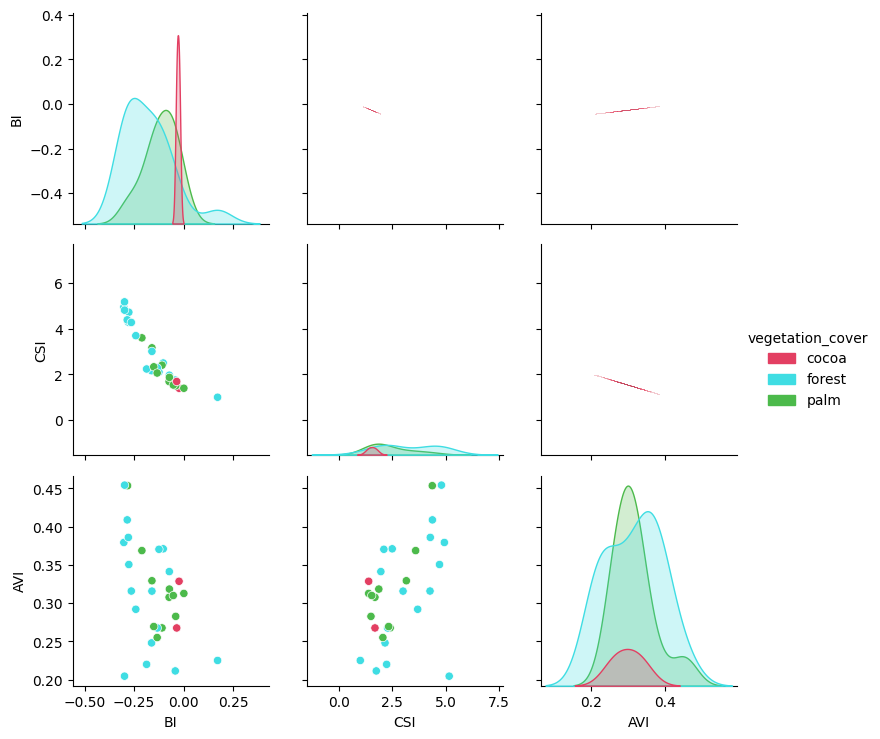

In [ ]:
# Create a color palette for plotting
colors = ["#E33F62","#3FDDE3","#4CBA4B"]

derived_train_indices = new_train_indices.copy()
derived_train_indices['vegetation_cover'] = sampled_train_data.Target.astype(int).map(id_to_labels)

sampled_data_to_plot = derived_train_indices.sample(n=30)

# Plots a pairplot to check the behaviour of derived indices
plt.figure(figsize=(15,20))
grid = sns.PairGrid(sampled_data_to_plot, hue="vegetation_cover",palette=sns.color_palette(colors))
grid.map_lower(sns.scatterplot)
grid.map_upper(sns.kdeplot, fill=True, alpha=.55)
grid.map_diag(sns.kdeplot, fill=True)
grid.add_legend()
plt.show()


Classification using random forest

In [ ]:
def resample_data(data : pd.DataFrame, time_column='time',group_key='ID') -> pd.DataFrame:
    data_grouped = data.groupby(by=group_key)
    dfs = []
    for group in data_grouped:
        resampled_group_data = data_grouped.get_group(group[0]).resample('18D', 
                                                                         on=time_column).agg('last').reset_index(drop=True)
        dfs.append(resampled_group_data)
    new_data =  pd.concat(dfs)
    return new_data.assign(timestep=(new_data.groupby(by=group_key).cumcount() + 1).map(lambda x : f"t{str(x).zfill(2)}"))
        

In [113]:
resampled_data = resample_data(full_train_data)
resampled_data.head()

,ID,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,...,Cirrus,NDVI,NDMI,NDWI,CI,Target,BI,CSI,AVI,timestep
0,1D_0000,0.2112,0.2304,0.2068,0.3637,0.3271,0.2158,0.2215,0.2821,0.3348,...,0.0014,0.275022,0.052982,-0.265264,0.034322,0.0,-0.053369,1.685357,0.356382,t01
1,1D_0000,0.0850,0.1072,0.0600,0.1736,0.0878,0.0343,0.0728,0.1355,0.1542,...,0.0019,0.486301,0.328233,-0.342614,0.096386,0.0,-0.310313,5.061224,0.264658,t02
2,1D_0000,0.1218,0.1431,0.0905,0.2803,0.1480,0.0598,0.1046,0.1729,0.2234,...,0.0005,0.511866,0.308896,-0.394181,0.072271,0.0,-0.279347,4.687291,0.364396,t03
3,1D_0000,0.1286,0.1451,0.1080,0.2401,0.1358,0.0665,0.1190,0.1675,0.1985,...,0.0008,0.379489,0.277467,-0.302414,0.048458,0.0,-0.224801,3.610526,0.304710,t04
4,1D_0000,0.1162,0.1337,0.0937,0.2457,0.1344,0.0639,0.1077,0.1596,0.1992,...,0.0007,0.447849,0.292818,-0.357834,0.069513,0.0,-0.249053,3.845070,0.323475,t05


In [119]:
target_values = resampled_data[['ID','Target']].groupby(by="ID").agg({"Target" : "last"})
target_values['Target'] = target_values.Target.astype(int)
target_values

,Target
ID,
1D_0000,0
1D_0001,0
1D_0002,0
1D_0003,0
1D_0004,0
...,...
id_362150a4e,1
id_36251804e,1
id_362957e2b,1


In [82]:
id_time_index_data = resampled_data.set_index(keys=['ID','timestep'])
id_time_index_data.head()

Green    Blue     RED     NIR   SWIR1   SWIR2  Red_Edge  \
ID      timestep                                                             
1D_0000 t01       0.2112  0.2304  0.2068  0.3637  0.3271  0.2158    0.2215   
        t02       0.0850  0.1072  0.0600  0.1736  0.0878  0.0343    0.0728   
        t03       0.1218  0.1431  0.0905  0.2803  0.1480  0.0598    0.1046   
        t04       0.1286  0.1451  0.1080  0.2401  0.1358  0.0665    0.1190   
        t05       0.1162  0.1337  0.0937  0.2457  0.1344  0.0639    0.1077   

                  Aerosols  Red_Edge_2  Red_Edge_3  ...  Water_vapor  Cirrus  \
ID      timestep                                    ...                        
1D_0000 t01         0.2821      0.3348      0.3921  ...       0.0802  0.0014   
        t02         0.1355      0.1542      0.1905  ...       0.0343  0.0019   
        t03         0.1729      0.2234      0.2938  ...       0.0377  0.0005   
        t04         0.1675      0.1985      0.2490  ...       0.0635  0.0008   
        t05         0.1596      0.1992      0.2485  ...       0.0714  0.0007   

                      NDVI      NDMI      NDWI        CI  Target        BI  \
ID      timestep                                                             
1D_0000 t01       0.275022  0.052982 -0.265264  0.034322     0.0 -0.053369   
        t02       0.486301  0.328233 -0.342614  0.096386     0.0 -0.310313   
        t03       0.511866  0.308896 -0.394181  0.072271     0.0 -0.279347   
        t04       0.379489  0.277467 -0.302414  0.048458     0.0 -0.224801   
        t05       0.447849  0.292818 -0.357834  0.069513     0.0 -0.249053   

                       CSI       AVI  
ID      timestep                      
1D_0000 t01       1.685357  0.356382  
        t02       5.061224  0.264658  
        t03       4.687291  0.364396  
        t04       3.610526  0.304710  
        t05       3.845070  0.323475  

[5 rows x 21 columns]

In [122]:
feat_columns = list(set(resampled_data.columns).difference(set(['ID','time','timestep','Target'])))

In [124]:
t = resampled_data.copy().drop(columns=['Target'])
t_grouped = t.pivot(index='ID',columns='timestep',values=feat_columns)
t_grouped.columns = [f"{col[0]}_{col[1]}" for col in t_grouped.columns]
t_grouped.head(10)

,SWIR2_t01,SWIR2_t02,SWIR2_t03,SWIR2_t04,SWIR2_t05,SWIR2_t06,SWIR2_t07,SWIR2_t08,SWIR2_t09,SWIR2_t10,...,SWIR1_t11,SWIR1_t12,SWIR1_t13,SWIR1_t14,SWIR1_t15,SWIR1_t16,SWIR1_t17,SWIR1_t18,SWIR1_t19,SWIR1_t20
ID,,,,,,,,,,,,,,,,,,,,,
1D_0000,0.2158,0.0343,0.0598,0.0665,0.0639,0.0449,0.2184,0.2184,0.2184,0.0541,...,0.2386,0.1172,0.1729,0.1729,0.1729,0.1729,0.1729,0.2068,0.2068,0.2068
1D_0001,0.0670,0.0224,0.0649,0.0706,0.0682,0.0542,0.2518,0.2518,0.2518,0.0641,...,0.2011,0.1315,0.2618,0.2618,0.2618,0.2618,0.2618,0.3160,0.3160,0.3160
1D_0002,0.1430,0.0373,0.0591,0.0655,0.0643,0.0467,0.2001,0.2001,0.2001,0.0533,...,0.2112,0.1466,0.1703,0.1703,0.1703,0.1703,0.1703,0.2283,0.2283,0.2283
1D_0003,0.1430,0.0373,0.0591,0.0655,0.0643,0.0467,0.2001,0.2001,0.2001,0.0533,...,0.2112,0.1466,0.1703,0.1703,0.1703,0.1703,0.1703,0.2283,0.2283,0.2283
1D_0004,0.1991,0.0423,0.0568,0.0639,0.0623,0.0445,0.1113,0.1113,0.1113,0.0579,...,0.2323,0.1573,0.1518,0.1518,0.1518,0.1518,0.1518,0.2709,0.2709,0.2709
1D_0006,0.0650,0.0209,0.0518,0.0634,0.0627,0.0455,0.1236,0.1236,0.1598,0.0591,...,0.1962,0.1495,0.2021,0.2021,0.2021,0.2021,0.2021,0.2196,0.2196,0.2196
1D_0007,0.0611,0.0219,0.0600,0.0684,0.0657,0.0486,0.2096,0.2096,0.2096,0.0538,...,0.1661,0.1403,0.2280,0.2280,0.2280,0.2280,0.2280,0.3565,0.3565,0.3565
1D_0008,0.0812,0.0232,0.0799,0.0758,0.0735,0.0632,0.1453,0.1453,0.1453,0.0739,...,0.1748,0.1926,0.2482,0.2482,0.2482,0.2482,0.2482,0.4333,0.4333,0.4333
1D_0009,0.0814,0.0357,0.0736,0.0761,0.0760,0.0706,0.0302,0.0302,0.0302,0.0655,...,0.2192,0.1376,0.2376,0.2376,0.2376,0.2376,0.2376,0.2393,0.2393,0.2393


In [125]:
merged_train_data = t_grouped.merge(target_values, on=['ID'])
merged_train_data.head()

,SWIR2_t01,SWIR2_t02,SWIR2_t03,SWIR2_t04,SWIR2_t05,SWIR2_t06,SWIR2_t07,SWIR2_t08,SWIR2_t09,SWIR2_t10,...,SWIR1_t12,SWIR1_t13,SWIR1_t14,SWIR1_t15,SWIR1_t16,SWIR1_t17,SWIR1_t18,SWIR1_t19,SWIR1_t20,Target
ID,,,,,,,,,,,,,,,,,,,,,
1D_0000,0.2158,0.0343,0.0598,0.0665,0.0639,0.0449,0.2184,0.2184,0.2184,0.0541,...,0.1172,0.1729,0.1729,0.1729,0.1729,0.1729,0.2068,0.2068,0.2068,0
1D_0001,0.0670,0.0224,0.0649,0.0706,0.0682,0.0542,0.2518,0.2518,0.2518,0.0641,...,0.1315,0.2618,0.2618,0.2618,0.2618,0.2618,0.3160,0.3160,0.3160,0
1D_0002,0.1430,0.0373,0.0591,0.0655,0.0643,0.0467,0.2001,0.2001,0.2001,0.0533,...,0.1466,0.1703,0.1703,0.1703,0.1703,0.1703,0.2283,0.2283,0.2283,0
1D_0003,0.1430,0.0373,0.0591,0.0655,0.0643,0.0467,0.2001,0.2001,0.2001,0.0533,...,0.1466,0.1703,0.1703,0.1703,0.1703,0.1703,0.2283,0.2283,0.2283,0
1D_0004,0.1991,0.0423,0.0568,0.0639,0.0623,0.0445,0.1113,0.1113,0.1113,0.0579,...,0.1573,0.1518,0.1518,0.1518,0.1518,0.1518,0.2709,0.2709,0.2709,0


In [126]:
merged_train_data.Target.value_counts()

Target
0    11918
2     9160
1     5141
Name: count, dtype: int64

In [ ]:


# Define the objective function for Optuna
def objective(trial):
    # Define hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Create the Random Forest model with the suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )

    # Perform stratified k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, t_grouped, target_values['Target'], cv=skf, scoring=make_scorer(accuracy_score))

    # Return the mean accuracy
    return scores.mean()

# Create an Optuna study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)


d:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge\amini\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-03-30 14:05:24,007] A new study created in memory with name: no-name-d7d124e1-7d78-4d88-9bc7-3124b243c54c
[I 2025-03-30 15:47:19,608] Trial 0 finished with value: 0.9945840976738008 and parameters: {'n_estimators': 147, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.9945840976738008.
[I 2025-03-30 15:49:04,291] Trial 1 finished with value: 0.9979785840639213 and parameters: {'n_estimators': 111, 'max_depth': 23, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 0.9979785840639213.
[W 2025-03-30 20:35:52,100] Trial 2 failed with parameters: {'n_estimators': 147, 'max

KeyboardInterrupt: 

In [128]:

# Train the final model with the best hyperparameters
best_params = study.best_params
best_params


{'n_estimators': 111,
 'max_depth': 23,
 'min_samples_split': 11,
 'min_samples_leaf': 6,
 'max_features': 'log2'}

In [ ]:
train_test_split

In [155]:
X_train, X_test, y_train, y_test = train_test_split(t_grouped, target_values['Target'],test_size=0.2, random_state=42, stratify=target_values['Target'])

In [152]:
t_grouped.columns

Index(['SWIR2_t01', 'SWIR2_t02', 'SWIR2_t03', 'SWIR2_t04', 'SWIR2_t05',
       'SWIR2_t06', 'SWIR2_t07', 'SWIR2_t08', 'SWIR2_t09', 'SWIR2_t10',
       ...
       'SWIR1_t11', 'SWIR1_t12', 'SWIR1_t13', 'SWIR1_t14', 'SWIR1_t15',
       'SWIR1_t16', 'SWIR1_t17', 'SWIR1_t18', 'SWIR1_t19', 'SWIR1_t20'],
      dtype='object', length=400)

In [132]:
final_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# Fit the model on the entire dataset
final_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=23, max_features='log2', min_samples_leaf=6,
                       min_samples_split=11, n_estimators=111, random_state=42)

In [133]:
final_model.score(X_test, y_test)

0.9982837528604119

In [186]:
grouped_test_data = full_test_data.groupby('ID')
new_test_df = pd.DataFrame()
new_dfs = []
for group in grouped_test_data:
    test_chip_data = grouped_test_data.get_group(group[0]).bfill().ffill().fillna(0)
    new_dfs.append(test_chip_data)
new_test_df = pd.concat(new_dfs)
new_test_df.head()

,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,...,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,BI,CSI,AVI
0,1D_0005,2023-11-20,0.0802,0.1017,0.0541,0.1970,0.1312,0.0536,0.0736,0.1342,...,0.2795,0.0400,0.0007,0.569096,0.200488,-0.421356,0.152702,-0.234298,3.675373,0.298617
1,1D_0005,2023-11-25,0.7069,0.6872,0.7779,0.7166,0.5160,0.3428,0.7593,0.7273,...,0.8646,0.1931,0.0018,-0.041017,0.162745,-0.006814,-0.012100,-0.040738,2.090432,0.208072
2,1D_0005,2023-11-30,0.1040,0.1320,0.0805,0.1471,0.0717,0.0349,0.0822,0.1627,...,0.1769,0.0183,0.0008,0.292619,0.344607,-0.171645,0.010449,-0.294227,4.214900,0.208072
3,1D_0005,2023-12-05,0.0910,0.1137,0.0643,0.2420,0.1677,0.0803,0.1036,0.1738,...,0.3215,0.0568,0.0011,0.580150,0.181352,-0.453453,0.234068,-0.210482,3.013699,0.342673
4,1D_0005,2023-12-10,0.0885,0.1083,0.0640,0.2064,0.1377,0.0649,0.0852,0.1406,...,0.2823,0.0467,0.0070,0.526627,0.199651,-0.399797,0.142091,-0.218823,3.180277,0.301878


In [187]:
new_test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1170240 entries, 0 to 1170239
Data columns (total 22 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   ID           1170240 non-null  object 
 1   time         1170240 non-null  object 
 2   Green        1170240 non-null  float64
 3   Blue         1170240 non-null  float64
 4   RED          1170240 non-null  float64
 5   NIR          1170240 non-null  float64
 6   SWIR1        1170240 non-null  float64
 7   SWIR2        1170240 non-null  float64
 8   Red_Edge     1170240 non-null  float64
 9   Aerosols     1170240 non-null  float64
 10  Red_Edge_2   1170240 non-null  float64
 11  Red_Edge_3   1170240 non-null  float64
 12  Red_Edge_4   1170240 non-null  float64
 13  Water_vapor  1170240 non-null  float64
 14  Cirrus       1170240 non-null  float64
 15  NDVI         1170240 non-null  float64
 16  NDMI         1170240 non-null  float64
 17  NDWI         1170240 non-null  float64
 18  CI     

In [188]:
new_test_df['time'] = pd.to_datetime(new_test_df['time'], errors='coerce')
resampled_test_data = resample_data(new_test_df)
resampled_test_data.head()

,ID,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,...,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,BI,CSI,AVI,timestep
0,1D_0005,0.0910,0.1137,0.0643,0.2420,0.1677,0.0803,0.1036,0.1738,0.2214,...,0.0568,0.0011,0.580150,0.181352,-0.453453,0.234068,-0.210482,3.013699,0.342673,t01
1,1D_0005,0.0783,0.1041,0.0564,0.1025,0.0466,0.0208,0.0615,0.1350,0.1005,...,0.0219,0.0020,0.290120,0.374916,-0.133850,0.043257,-0.334625,4.927885,0.164590,t02
2,1D_0005,0.1134,0.1381,0.0846,0.2282,0.1485,0.0610,0.1003,0.1695,0.2034,...,0.0376,0.0008,0.459079,0.211574,-0.336066,0.084911,-0.222222,3.740984,0.310714,t03
3,1D_0005,0.1279,0.1439,0.1082,0.2303,0.1379,0.0669,0.1175,0.1679,0.1960,...,0.0631,0.0009,0.360709,0.250951,-0.285874,0.041205,-0.206513,3.442451,0.292702,t04
4,1D_0005,0.1162,0.1335,0.0933,0.2265,0.1363,0.0656,0.1063,0.1603,0.1953,...,0.0723,0.0009,0.416510,0.248622,-0.321856,0.065130,-0.221167,3.452744,0.301309,t05


In [189]:
test_pivoted_data = resampled_test_data.pivot(index='ID',columns='timestep',values=feat_columns)
test_pivoted_data.columns = [f"{col[0]}_{col[1]}" for col in test_pivoted_data.columns]

In [190]:
test_pivoted_data.head()

,SWIR2_t01,SWIR2_t02,SWIR2_t03,SWIR2_t04,SWIR2_t05,SWIR2_t06,SWIR2_t07,SWIR2_t08,SWIR2_t09,SWIR2_t10,...,SWIR1_t11,SWIR1_t12,SWIR1_t13,SWIR1_t14,SWIR1_t15,SWIR1_t16,SWIR1_t17,SWIR1_t18,SWIR1_t19,SWIR1_t20
ID,,,,,,,,,,,,,,,,,,,,,
1D_0005,0.0803,0.0208,0.0610,0.0669,0.0656,0.0487,0.1146,0.1146,0.1248,0.0629,...,0.2047,0.1503,0.2040,0.2040,0.2040,0.2040,0.2040,0.1917,0.1917,0.1917
1D_000A,0.0589,0.0434,0.0446,0.0701,0.0702,0.0573,0.0334,0.0334,0.0334,0.0650,...,0.2177,0.0636,0.2905,0.2905,0.2905,0.2905,0.2905,0.2905,0.2905,0.2905
1D_000D,0.0777,0.0222,0.0691,0.0721,0.0698,0.0544,0.1904,0.1904,0.0537,0.0596,...,0.2498,0.1472,0.2721,0.2721,0.2721,0.2721,0.2721,0.5202,0.5202,0.5202
1D_000E,0.1323,0.0229,0.0653,0.0708,0.0700,0.0552,0.2326,0.2326,0.0334,0.0640,...,0.2619,0.1793,0.2701,0.2701,0.2701,0.2701,0.2701,0.5086,0.5086,0.5086
1D_0015,0.0938,0.0272,0.0595,0.0729,0.0721,0.0620,0.2524,0.2524,0.2171,0.0714,...,0.2085,0.0448,0.2381,0.2381,0.2381,0.2381,0.2381,0.2232,0.4417,0.4417


In [191]:
test_pivoted_data.shape

(16960, 400)

In [192]:
test_pivoted_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16960 entries, 1D_0005 to id_ffe082a9c
Columns: 400 entries, SWIR2_t01 to SWIR1_t20
dtypes: float64(400)
memory usage: 51.9+ MB


In [193]:
test_preds = final_model.predict(test_pivoted_data)


In [194]:
submission_data = test_pivoted_data.reset_index()[['ID']]
submission_data['Target'] = test_preds

In [210]:
submission_data.head()

,ID,Target
0,1D_0005,0
1,1D_000A,0
2,1D_000D,0
3,1D_000E,0
4,1D_0015,0


In [196]:
submission_data.Target.value_counts()

Target
0    7383
1    5634
2    3943
Name: count, dtype: int64

In [197]:
submissions_dir = REPORTS_DIR / 'zindi_submissions'
submissions_dir.mkdir(exist_ok=True, parents=True)

In [198]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%M%d_%H%M%S")
sub_filename = submissions_dir / f"{timestamp}.csv"
with sub_filename.open(mode="w") as fp:
    submission_data.to_csv(fp, index=False)


Try catboost search or xgboost

In [200]:
import numpy as np
import torch

In [201]:
cuda_available = torch.cuda.is_available()

In [206]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

# Define the objective function for Optuna
def xgb_objective(trial):
    # Define hyperparameters to tune
    param = {
        'objective': 'multi:softmax',
        'tree_method' : 'gpu_hist' if cuda_available else 'hist',
        'num_class': len(np.unique(y_train)),
        'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state' : 42,
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Train the model
    model = xgb.train(param, dtrain, num_boost_round=100, evals=[(dtest, 'eval')], early_stopping_rounds=10,
                      verbose_eval=False)

    # Predict and calculate accuracy
    preds = model.predict(dtest)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

# Create an Optuna study and optimize
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=40)

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

# Train the final model with the best hyperparameters
xgb_best_params = xgb_study.best_params
xgb_best_params['objective'] = 'multi:softmax'
xgb_best_params['num_class'] = len(np.unique(y_train))
xgb_best_params['random_state'] = 42

xgb_model = xgb.train(xgb_best_params, xgb.DMatrix(X_train, label=y_train), num_boost_round=100)

# Evaluate the final model
final_preds = xgb_model.predict(xgb.DMatrix(X_test))
final_accuracy = accuracy_score(y_test, final_preds)
print(f"Final XGB model accuracy: {final_accuracy}")

[I 2025-03-30 22:59:38,063] A new study created in memory with name: no-name-69fb8c31-5f71-4a2c-859b-71cb7fee0296
d:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge\amini\Lib\site-packages\xgboost\callback.py:386: UserWarning: [22:59:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  self.starting_round = model.num_boosted_rounds()
[I 2025-03-30 22:59:41,514] Trial 0 finished with value: 0.9782608695652174 and parameters: {'learning_rate': 0.0455589251714615, 'max_depth': 3, 'min_child_weight': 5.972015855217126, 'gamma': 0.454026264157833, 'subsample': 0.9403482738969073, 'colsample_bytree': 0.6822829818122318}. Best is trial 0 with value: 0.9782608695652174.
d:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge\amini\Lib\site-packages\xgboost\callback.py:386: UserWarning: [22:59:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_w

Best hyperparameters: {'n_estimators': 111, 'max_depth': 23, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2'}
Final XGB model accuracy: 0.9998093058733791


In [207]:
xgb_best_params

{'learning_rate': 0.11210609385710024,
 'max_depth': 8,
 'min_child_weight': 4.63744958310525,
 'gamma': 0.3218480348461351,
 'subsample': 0.7482596580140176,
 'colsample_bytree': 0.6394722235453142,
 'objective': 'multi:softmax',
 'num_class': 3,
 'scale_pos_weight': np.float64(1.699894643001864),
 'random_state': 42}

In [208]:
xgb_test_data = xgb.DMatrix(test_pivoted_data)
xgb_test_preds = xgb_model.predict(xgb_test_data)

In [211]:
xgb_submission_data = submission_data.copy()[['ID']]
xgb_submission_data['Target'] = xgb_test_preds.astype(int)
xgb_submission_data.head()

,ID,Target
0,1D_0005,0
1,1D_000A,0
2,1D_000D,0
3,1D_000E,0
4,1D_0015,0


In [212]:
timestamp = datetime.now().strftime("%Y%M%d_%H%M%S")
sub_filename = submissions_dir / f"xgb_{timestamp}.csv"
with sub_filename.open(mode="w") as fp:
    xgb_submission_data.to_csv(fp, index=False)